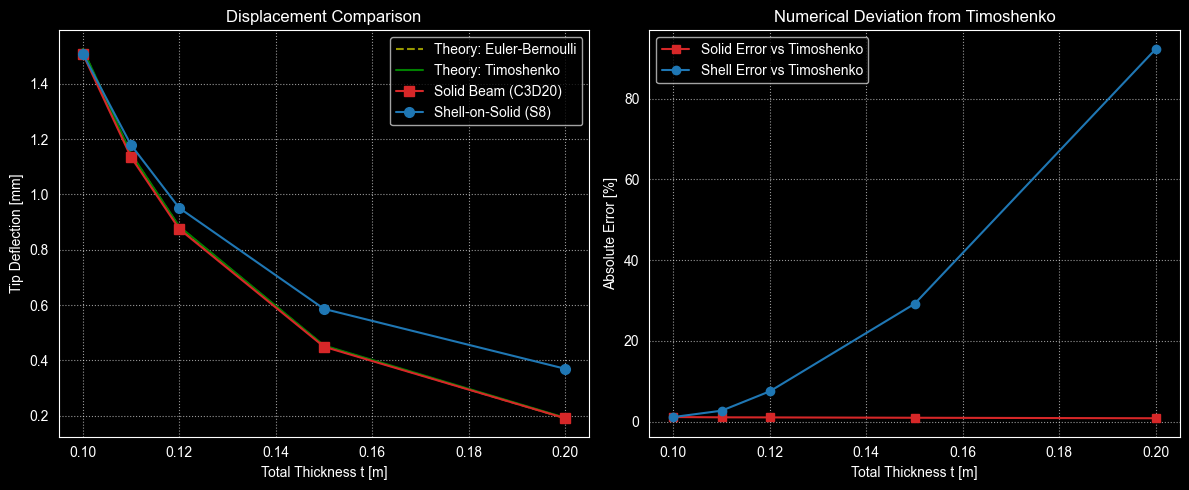

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Given Parameters
L = 2        # Beam length [m]
b = 0.1      # Beam width [m]
E = 210e9    # Young's Modulus [Pa]
nu = 0.3     # Poisson's ratio
F = 1000.0   # Total Tip Force [N]
k = 5/6      # Shear correction factor

# Thicknesses and corresponding FE results
t = np.array([0.10, 0.11, 0.12, 0.15, 0.20])

# Scenario 2: Pure Solid Results (C3D20)
u_FE_solid = np.array([1.50900e-03, 1.1350e-03, 0.874800e-03, 0.44900e-03, 0.190300e-03])

# Scenario 3: Shell-on-Solid Results (S8 + C3D20)
u_FE_shell = np.array([1.50900e-03, 1.1790e-03, 0.9510e-03, 0.58590e-03, 0.36920e-03])

# 2. Analytical Calculations
I = b * t**3 / 12.0
u_bernoulli = F * L**3 / (3 * E * I)

G = E / (2 * (1 + nu))
A = b * t
u_shear = F * L / (k * G * A)
u_timoshenko = u_bernoulli + u_shear # The "True" physics benchmark

# 3. Error Analysis (relative to Timoshenko)
error_solid = (u_FE_solid - u_timoshenko) / u_timoshenko * 100.0
error_shell = (u_FE_shell - u_timoshenko) / u_timoshenko * 100.0

# --- Plotting with Clean White Background ---
plt.figure(figsize=(12, 5))

# Plot A: Displacement Comparison
plt.subplot(1, 2, 1)
plt.plot(t, u_bernoulli * 1e3, '--', color='yellow', label='Theory: Euler-Bernoulli', alpha=0.6)
plt.plot(t, u_timoshenko * 1e3, '-', color='green', label='Theory: Timoshenko', linewidth=1.5)
plt.plot(t, u_FE_solid * 1e3, 's-', color='#d62728', label='Solid Beam (C3D20)', markersize=7)
plt.plot(t, u_FE_shell * 1e3, 'o-', color='#1f77b4', label='Shell-on-Solid (S8)', markersize=7)

plt.xlabel('Total Thickness t [m]')
plt.ylabel('Tip Deflection [mm]')
plt.title('Displacement Comparison')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot B: Error Analysis
plt.subplot(1, 2, 2)
plt.plot(t, np.abs(error_solid), 's-', color='#d62728', label='Solid Error vs Timoshenko')
plt.plot(t, np.abs(error_shell), 'o-', color='#1f77b4', label='Shell Error vs Timoshenko')

plt.xlabel('Total Thickness t [m]')
plt.ylabel('Absolute Error [%]')
plt.title('Numerical Deviation from Timoshenko')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('beam_comparison_clean.png', dpi=300)
plt.show()